In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.mixture import GaussianMixture

## K means na dveh Gaussovih porazdelitvah

- Lastna implementacija K means

In [22]:
def k_means(data, K=2, max_iter=100, tol=1e-6, random_state=42):
    """
    Lastna implementacija algoritma K-means.

    Parameters
    ----------
    data : ndarray, shape (N, d)
        Vhodne točke.
    K : int
        Število gruč.
    max_iter : int
        Največje število iteracij.
    tol : float
        Toleranca za konvergenco centroidov.
    random_state : int
        Seme generatorja naključnih števil.

    Returns
    -------
    labels : ndarray, shape (N,)
        Oznaka gruče za vsako točko.
    centroids : ndarray, shape (K, d)
        Končni centroidi.
    n_iter : int
        Število izvedenih iteracij.
    """

    rng = np.random.default_rng(random_state)

    N = len(data)

    # Začetne centroide izberemo kot K naključnih podatkovnih točk
    initial_indices = rng.choice(N, size=K, replace=False)
    centroids = data[initial_indices].copy()

    for iteration in range(max_iter):

        # Razdalja vsake točke do vsakega centroida
        # rezultat ima obliko (N, K)
        distances = np.linalg.norm(
            data[:, np.newaxis, :] - centroids[np.newaxis, :, :],
            axis=2
        )

        # Vsaki točki pripišemo najbližji centroid
        labels = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)

        for k in range(K):
            cluster_points = data[labels == k]

            # Zaščita pred prazno gručo
            if len(cluster_points) == 0:
                new_centroids[k] = data[rng.integers(N)]
            else:
                new_centroids[k] = np.mean(cluster_points, axis=0)

        # Premik centroidov med dvema iteracijama
        centroid_shift = np.linalg.norm(new_centroids - centroids)

        centroids = new_centroids

        if centroid_shift < tol:
            break

    return labels, centroids, iteration + 1

In [23]:
gauss_data = (
    "/home/tadej/Desktop/STUDIJ/mag-2.letnik/"
    "PSUF/PSUF6/data/gauss.npy"
)

data = np.load(gauss_data)

labels_kmeans, centroids, n_iter = k_means(
    data,
    K=2,
    random_state=42
)

print("Število iteracij:", n_iter)
print("Centroidi:")
print(centroids)

Število iteracij: 4
Centroidi:
[[-1.45467308 -0.49259767]
 [ 1.49244299  0.79561583]]


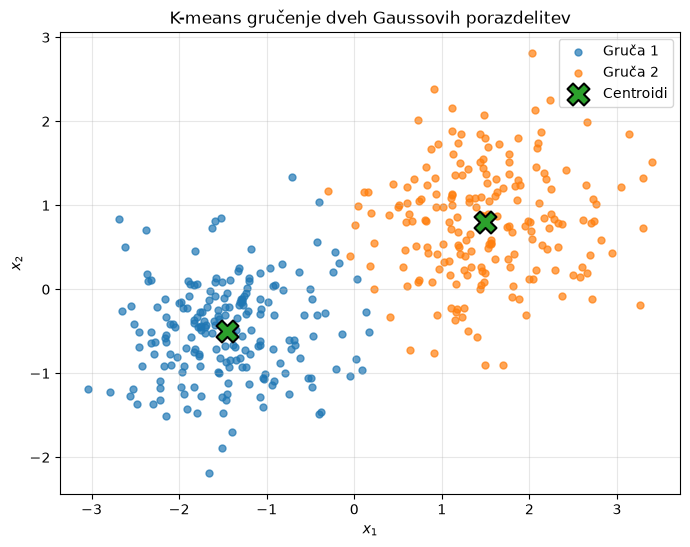

In [24]:
plt.figure(figsize=(8, 6))

for k in range(2):
    cluster_points = data[labels_kmeans == k]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=25,
        alpha=0.7,
        label=f"Gruča {k + 1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroidi"
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("K-means gručenje dveh Gaussovih porazdelitev")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
for k in range(2):
    cluster_points = data[labels_kmeans == k]

    mean = np.mean(cluster_points, axis=0)
    std = np.std(cluster_points, axis=0, ddof=1)

    print(f"\nGruča {k + 1}")
    print(f"Število točk: {len(cluster_points)}")
    print(f"Povprečje: mu_x = {mean[0]:.4f}, mu_y = {mean[1]:.4f}")
    print(f"Std. odklon: sigma_x = {std[0]:.4f}, sigma_y = {std[1]:.4f}")


Gruča 1
Število točk: 203
Povprečje: mu_x = -1.4547, mu_y = -0.4926
Std. odklon: sigma_x = 0.6472, sigma_y = 0.5711

Gruča 2
Število točk: 197
Povprečje: mu_x = 1.4924, mu_y = 0.7956
Std. odklon: sigma_x = 0.7283, sigma_y = 0.6703


- Implementacija GMM

In [26]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(data)

labels_gmm = gmm.predict(data)

gmm_means = gmm.means_
gmm_covariances = gmm.covariances_

gmm_stds = np.sqrt(
    np.diagonal(gmm_covariances, axis1=1, axis2=2)
)

order = np.argsort(gmm_means[:, 0])

gmm_means = gmm_means[order]
gmm_stds = gmm_stds[order]
gmm_covariances = gmm_covariances[order]

for k in range(2):
    print(f"GMM, Gaussova porazdelitev {k + 1}:")
    print(
        f"  mu_x = {gmm_means[k, 0]:.4f}, "
        f"mu_y = {gmm_means[k, 1]:.4f}"
    )
    print(
        f"  sigma_x = {gmm_stds[k, 0]:.4f}, "
        f"sigma_y = {gmm_stds[k, 1]:.4f}"
    )

GMM, Gaussova porazdelitev 1:
  mu_x = -1.4992, mu_y = -0.5195
  sigma_x = 0.6126, sigma_y = 0.5476
GMM, Gaussova porazdelitev 2:
  mu_x = 1.4281, mu_y = 0.7746
  sigma_x = 0.7883, sigma_y = 0.6774


- Skupna primerjava

In [27]:
kmeans_means = np.zeros((2, 2))
kmeans_stds = np.zeros((2, 2))
kmeans_counts = np.zeros(2, dtype=int)

for k in range(2):
    cluster_points = data[labels_kmeans == k]

    kmeans_means[k] = np.mean(cluster_points, axis=0)
    kmeans_stds[k] = np.std(cluster_points, axis=0, ddof=1)
    kmeans_counts[k] = len(cluster_points)


# Gruči uredimo glede na x-koordinato centroida:
# prva bo leva, druga desna Gaussova porazdelitev.
order_kmeans = np.argsort(kmeans_means[:, 0])

kmeans_means = kmeans_means[order_kmeans]
kmeans_stds = kmeans_stds[order_kmeans]
kmeans_counts = kmeans_counts[order_kmeans]


# ============================================================
# 2. Gaussian Mixture Model
# ============================================================

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(data)

labels_gmm = gmm.predict(data)

gmm_means = gmm.means_

# Diagonalni elementi kovariančne matrike so variance
gmm_stds = np.sqrt(
    np.diagonal(
        gmm.covariances_,
        axis1=1,
        axis2=2
    )
)

gmm_counts = np.bincount(labels_gmm, minlength=2)


# Tudi komponenti GMM uredimo glede na x-koordinato povprečja
order_gmm = np.argsort(gmm_means[:, 0])

gmm_means = gmm_means[order_gmm]
gmm_stds = gmm_stds[order_gmm]
gmm_counts = gmm_counts[order_gmm]


# ============================================================
# 3. Skupna tabela
# ============================================================

comparison = pd.DataFrame({
    "Metoda": [
        "K-means",
        "GMM",
        "K-means",
        "GMM"
    ],
    "Porazdelitev": [
        "Gauss 1",
        "Gauss 1",
        "Gauss 2",
        "Gauss 2"
    ],
    "N": [
        kmeans_counts[0],
        gmm_counts[0],
        kmeans_counts[1],
        gmm_counts[1]
    ],
    "mu_x": [
        kmeans_means[0, 0],
        gmm_means[0, 0],
        kmeans_means[1, 0],
        gmm_means[1, 0]
    ],
    "mu_y": [
        kmeans_means[0, 1],
        gmm_means[0, 1],
        kmeans_means[1, 1],
        gmm_means[1, 1]
    ],
    "sigma_x": [
        kmeans_stds[0, 0],
        gmm_stds[0, 0],
        kmeans_stds[1, 0],
        gmm_stds[1, 0]
    ],
    "sigma_y": [
        kmeans_stds[0, 1],
        gmm_stds[0, 1],
        kmeans_stds[1, 1],
        gmm_stds[1, 1]
    ]
})

print(comparison.round(4))

    Metoda Porazdelitev    N    mu_x    mu_y  sigma_x  sigma_y
0  K-means      Gauss 1  203 -1.4547 -0.4926   0.6472   0.5711
1      GMM      Gauss 1  194 -1.4992 -0.5195   0.6126   0.5476
2  K-means      Gauss 2  197  1.4924  0.7956   0.7283   0.6703
3      GMM      Gauss 2  206  1.4281  0.7746   0.7883   0.6774


## K means na hadronskih curkih